In [1]:
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install tensorboard
%load_ext tensorboard
!pip install torch --upgrade --force-reinstall

  Using cached torch-2.5.1-cp310-cp310-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached filelock-3.16.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.5-py3-none-any.whl.metadata (2.6 kB)
  Using cached fsspec-2024.12.0-py3-none-any.whl.metadata (11 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Usi

# **DQN agent with simple binary rewards for storage volume constraints with smaller time steps (threshold) each episode**

In [2]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Discrete, Box
from stable_baselines3 import DQN
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1600000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
release_cfs = [1000, 2000, 3000]  # Define discrete release values (cfs)
release_af = [r * 1.98211 for r in release_cfs]  # Convert cfs to acre-feet

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, data, scaler, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = data
        self.scaler = scaler
        self.episode_length = episode_length
        self.current_step = 0
        self.storage_history = []
        self.predicted_release_history = []
        self.reward_history = []
        self.q_values = []

        # Unscaled data for actual values
        unscaled_data = self.scaler.inverse_transform(self.data)
        self.actual_storage_history = unscaled_data[:, 0].tolist()
        self.actual_release_history = unscaled_data[:, 3].tolist()
        self.evaporation_history = unscaled_data[:, 1].tolist()
        self.inflow_history = unscaled_data[:, 2].tolist()

        # Define action space and observation space
        self.action_space = Discrete(len(release_af))  # Actions: release values in af
        self.observation_space = Box(low=0, high=1, shape=(3,), dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count=0
        self.storage_history.clear()
        self.predicted_release_history.clear()
        self.reward_history.clear()
        self.q_values.clear()

        # Set the storage to the value corresponding to the start of the episode
        self.current_storage = self.scaler.inverse_transform(self.data[self.current_step:self.current_step + 1, :])[0, 0]
        self.storage_history.append(self.current_storage)
        return self._get_observation(), {}

    def _get_observation(self):
        return self.data[self.current_step, :3]

    def step(self, action):
        release_af_value = release_af[action]  # Map action index to release value
        inflow_af = self.scaler.inverse_transform(self.data[self.current_step:self.current_step + 1, :])[0, 2]
        evaporation_af = self.scaler.inverse_transform(self.data[self.current_step:self.current_step + 1, :])[0, 1]

        # Update storage with inflow, evaporation, and release
        self.current_storage += inflow_af - evaporation_af - release_af_value
        self.predicted_release_history.append(release_af_value)
        self.storage_history.append(self.current_storage)

        # Reward calculation
        if min_storage_af <= self.current_storage <= max_storage_af:
            reward = 1  # Positive reward for staying within bounds
        else:
            reward = -1  # Negative reward for going out of bounds

        self.reward_history.append(reward)
        self.current_step += 1
        self.episode_step_count+=1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)
        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

    def render(self, mode='human', close=False):
        pass


# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset)

# Set up environment
episode_length = 120
env = ReservoirEnv(scaled_data, scaler, episode_length=episode_length)

# Initializing DQN model
model = DQN("MlpPolicy", env, verbose=1)

# Training the model
n_episodes = 20000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Saving the model
model.save("dqn_reservoir_agent")

Streaming output truncated to the last 5000 lines.
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.298    |
|    n_updates        | 560014   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 115      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 18672    |
|    fps              | 570      |
|    time_elapsed     | 3926     |
|    total_timesteps  | 2240640  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.85     |
|    n_updates        | 560134   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 112      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 18676    |
|   

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Analysis results saved to 'dqn_analysis_results.csv'.


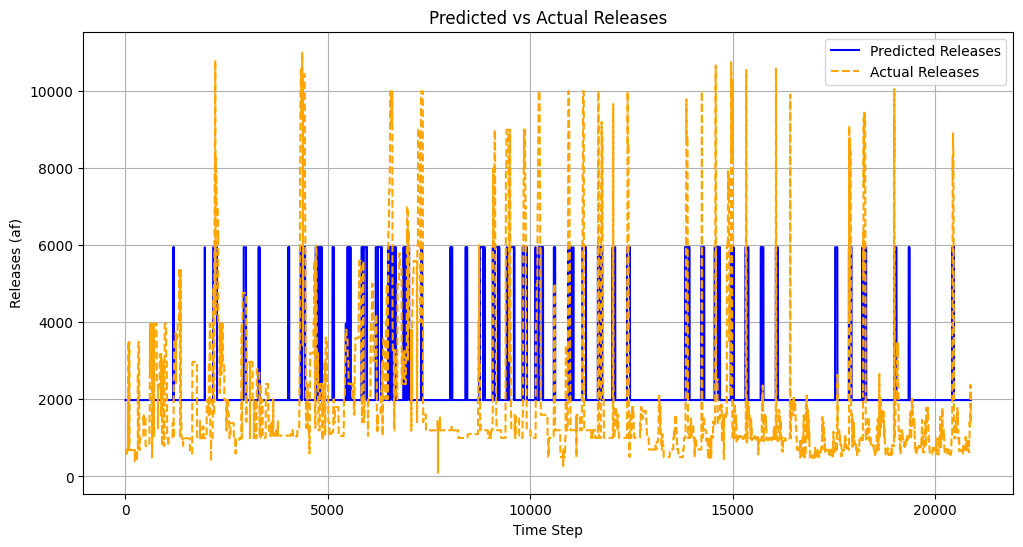

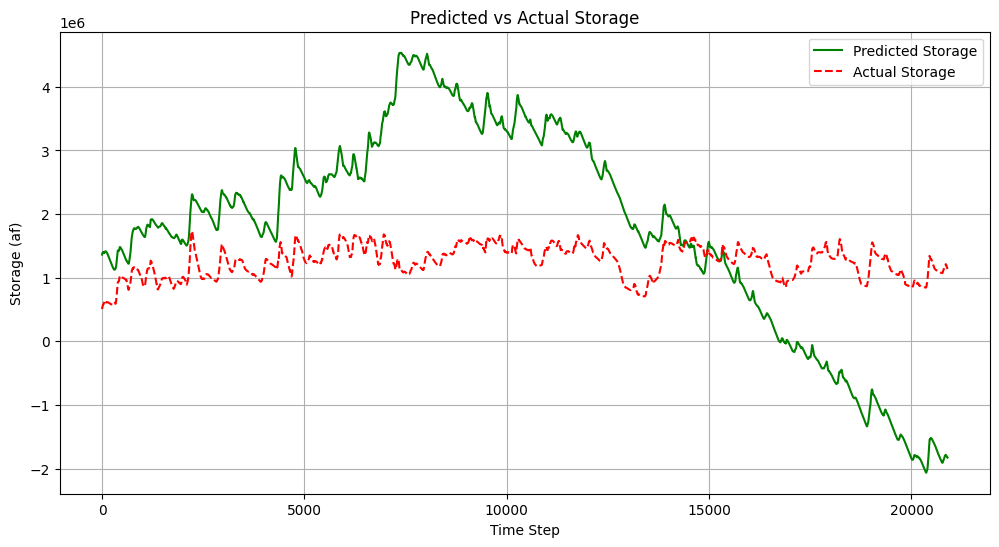

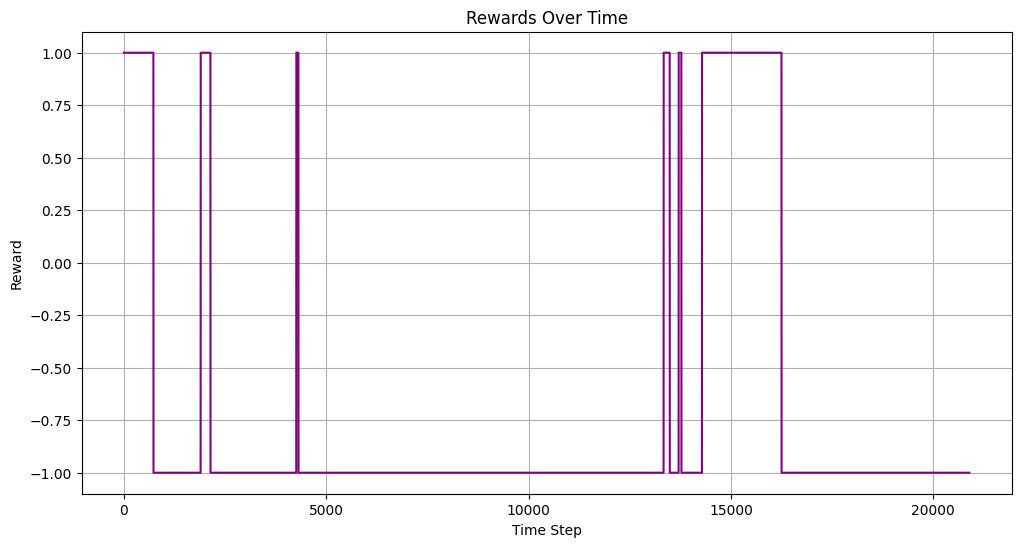

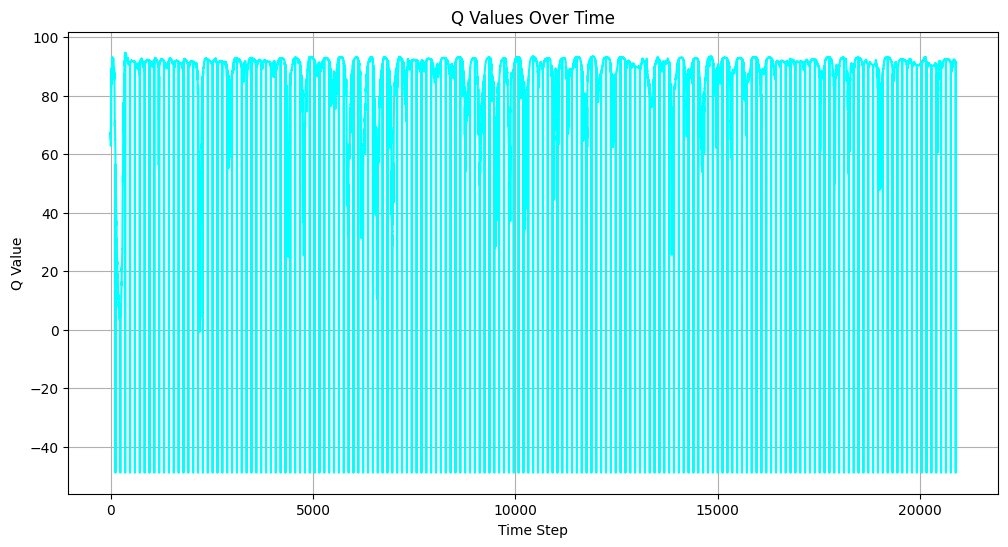

In [3]:
# Load the trained DQN agent
model = DQN.load("dqn_reservoir_agent")

# Reset the environment and initialize analysis lists
env = ReservoirEnv(scaled_data, scaler, episode_length=episode_length)
obs, _ = env.reset()

predicted_releases = []
actual_releases = []
predicted_storage = []
actual_storage = []
rewards = []
q_values = []

# Simulate the entire dataset
env.current_step = 0  # Start from the beginning of the dataset
done = False

while env.current_step < len(env.data):
    action, _ = model.predict(obs, deterministic=True)  # Get action from DQN agent
    obs, reward, done, _, _ = env.step(action)  # Step through the environment

    # Capture data for analysis
    predicted_releases.append(env.predicted_release_history[-1])
    actual_releases.append(env.actual_release_history[env.current_step - 1])
    predicted_storage.append(env.storage_history[-1])
    actual_storage.append(env.actual_storage_history[env.current_step - 1])
    rewards.append(reward)

    # Compute Q-values for the current observation
    q_value = model.q_net(th.tensor(obs, dtype=th.float32).unsqueeze(0)).detach().numpy().max()
    q_values.append(q_value)

    # Stop if the end of the dataset is reached
    if env.current_step >= len(env.data) - 1:
        break

# Save analysis results to CSV
results_df = pd.DataFrame({
    "Time Step": range(len(predicted_releases)),
    "Predicted Releases (af)": predicted_releases,
    "Actual Releases (af)": actual_releases,
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage,
    "Rewards": rewards,
    "Q Values": q_values,
})
results_df.to_csv("dqn_analysis_results.csv", index=False)
print("Analysis results saved to 'dqn_analysis_results.csv'.")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(predicted_releases, label="Predicted Releases", color="blue")
plt.plot(actual_releases, label="Actual Releases", linestyle="--", color="orange")
plt.xlabel("Time Step")
plt.ylabel("Releases (af)")
plt.legend()
plt.title("Predicted vs Actual Releases")
plt.grid()
plt.savefig("predicted_vs_actual_releases.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(predicted_storage, label="Predicted Storage", color="green")
plt.plot(actual_storage, label="Actual Storage", linestyle="--", color="red")
plt.xlabel("Time Step")
plt.ylabel("Storage (af)")
plt.legend()
plt.title("Predicted vs Actual Storage")
plt.grid()
plt.savefig("predicted_vs_actual_storage.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(rewards, label="Rewards", color="purple")
plt.xlabel("Time Step")
plt.ylabel("Reward")
plt.title("Rewards Over Time")
plt.grid()
plt.savefig("rewards_over_time.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(q_values, label="Q Values", color="cyan")
plt.xlabel("Time Step")
plt.ylabel("Q Value")
plt.title("Q Values Over Time")
plt.grid()
plt.savefig("q_values_over_time.png")
plt.show()